In [4]:
# Cell 1: Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, silhouette_score

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

In [5]:
# Load Dataset from Kaggle

df = pd.read_csv(
    "/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv"
)

dictionary = pd.read_csv(
    "/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv"
)

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [6]:
# Cell 3: Basic Data Exploration

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

df.describe()

Dataset Shape: (167, 10)

Columns:
Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

Missing Values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [7]:
# Cell 4: Create Classification Target

# Creating development category using GDPP and income
# This converts the dataset into a supervised classification problem.

def classify_country(row):
    if row["gdpp"] < df["gdpp"].quantile(0.33) and row["income"] < df["income"].quantile(0.33):
        return "Low Development"
    elif row["gdpp"] > df["gdpp"].quantile(0.66) and row["income"] > df["income"].quantile(0.66):
        return "High Development"
    else:
        return "Medium Development"

df["development_category"] = df.apply(classify_country, axis=1)

df[["country", "income", "gdpp", "development_category"]].head()

,country,income,gdpp,development_category
0,Afghanistan,1610,553,Low Development
1,Albania,9930,4090,Medium Development
2,Algeria,12900,4460,Medium Development
3,Angola,5900,3530,Medium Development
4,Antigua and Barbuda,19100,12200,High Development


In [10]:
# Cell 5: Prepare Data for Classification

X = df.drop(["country", "development_category"], axis=1)
y = df["development_category"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [11]:
# Cell 6: Random Forest Classification

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=label_encoder.classes_))

Random Forest Accuracy: 1.0

Classification Report:
                    precision    recall  f1-score   support

  High Development       1.00      1.00      1.00        11
   Low Development       1.00      1.00      1.00        10
Medium Development       1.00      1.00      1.00        13

          accuracy                           1.00        34
         macro avg       1.00      1.00      1.00        34
      weighted avg       1.00      1.00      1.00        34



In [12]:
# Cell 7: XGBoost Classification

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    objective="multi:softmax",
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred, target_names=label_encoder.classes_))

XGBoost Accuracy: 1.0

Classification Report:
                    precision    recall  f1-score   support

  High Development       1.00      1.00      1.00        11
   Low Development       1.00      1.00      1.00        10
Medium Development       1.00      1.00      1.00        13

          accuracy                           1.00        34
         macro avg       1.00      1.00      1.00        34
      weighted avg       1.00      1.00      1.00        34



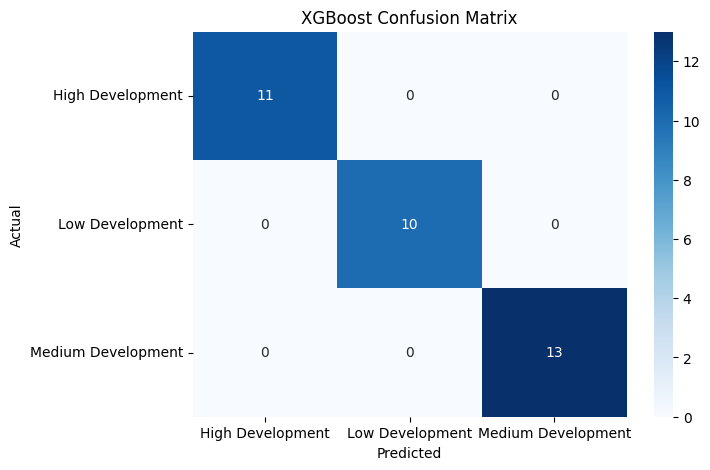

In [13]:
# Cell 8: Confusion Matrix

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

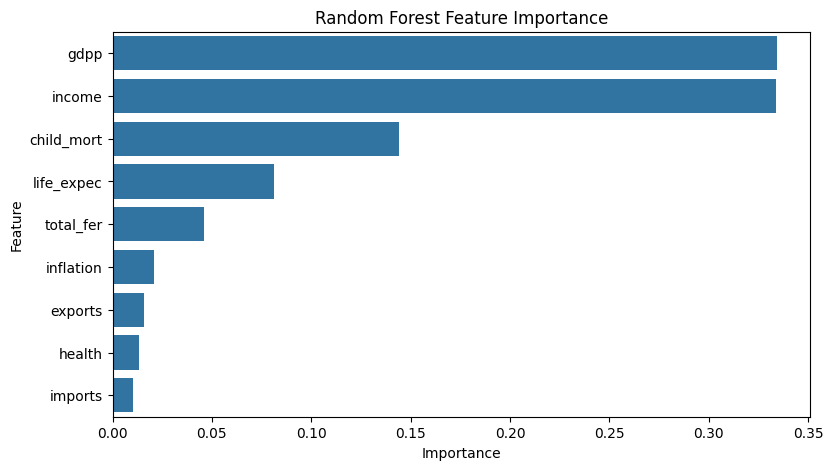

,Feature,Importance
8,gdpp,0.334176
4,income,0.333858
0,child_mort,0.144302
6,life_expec,0.081093
7,total_fer,0.045802
5,inflation,0.020911
1,exports,0.016077
2,health,0.013517
3,imports,0.010265


In [14]:
# Cell 9: Feature Importance - Random Forest

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("Random Forest Feature Importance")
plt.show()

feature_importance

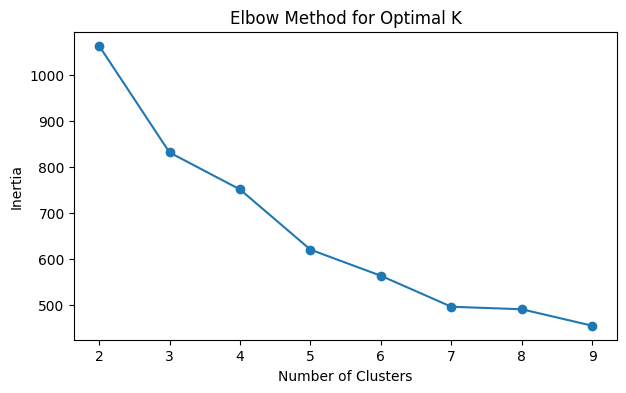

In [15]:
# Cell 10: K-Means Clustering

cluster_features = df.drop(["country", "development_category"], axis=1)
cluster_scaled = scaler.fit_transform(cluster_features)

inertia = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(range(2, 10), inertia, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [16]:
# Cell 11: Apply K-Means

kmeans = KMeans(n_clusters=3, random_state=42)
df["kmeans_cluster"] = kmeans.fit_predict(cluster_scaled)

print("Silhouette Score:", silhouette_score(cluster_scaled, df["kmeans_cluster"]))

df[["country", "kmeans_cluster"]].head()

Silhouette Score: 0.285600988953231


,country,kmeans_cluster
0,Afghanistan,2
1,Albania,0
2,Algeria,0
3,Angola,2
4,Antigua and Barbuda,0


In [17]:
# Cell 12: DBSCAN Clustering

dbscan = DBSCAN(eps=2.2, min_samples=4)
df["dbscan_cluster"] = dbscan.fit_predict(cluster_scaled)

print("DBSCAN Clusters:")
print(df["dbscan_cluster"].value_counts())

df[["country", "dbscan_cluster"]].head()

DBSCAN Clusters:
dbscan_cluster
 0    158
-1      9
Name: count, dtype: int64


,country,dbscan_cluster
0,Afghanistan,0
1,Albania,0
2,Algeria,0
3,Angola,0
4,Antigua and Barbuda,0


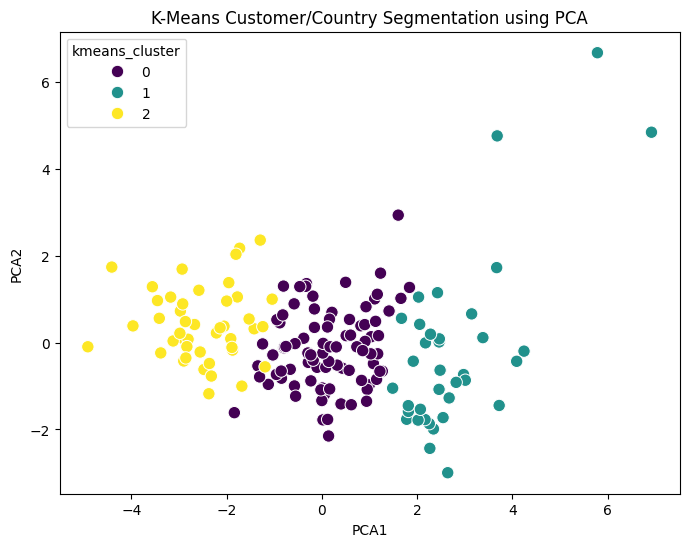

In [18]:
# Cell 13: PCA Visualization for Clusters

pca = PCA(n_components=2)
pca_data = pca.fit_transform(cluster_scaled)

df["PCA1"] = pca_data[:, 0]
df["PCA2"] = pca_data[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="kmeans_cluster",
    palette="viridis",
    s=80
)

plt.title("K-Means Customer/Country Segmentation using PCA")
plt.show()

In [19]:
# Cell 14: Cluster Profiling

cluster_profile = df.groupby("kmeans_cluster")[X.columns].mean()
cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111


In [20]:
# Cell 15: Actionable Segment Insights

for cluster in sorted(df["kmeans_cluster"].unique()):
    print(f"\nCluster {cluster} Countries:")
    print(df[df["kmeans_cluster"] == cluster]["country"].values)

    print("\nAverage Profile:")
    print(cluster_profile.loc[cluster])


Cluster 0 Countries:
['Albania' 'Algeria' 'Antigua and Barbuda' 'Argentina' 'Armenia'
 'Azerbaijan' 'Bahamas' 'Bangladesh' 'Barbados' 'Belarus' 'Belize'
 'Bhutan' 'Bolivia' 'Bosnia and Herzegovina' 'Botswana' 'Brazil'
 'Bulgaria' 'Cambodia' 'Cape Verde' 'Chile' 'China' 'Colombia'
 'Costa Rica' 'Croatia' 'Dominican Republic' 'Ecuador' 'Egypt'
 'El Salvador' 'Estonia' 'Fiji' 'Georgia' 'Grenada' 'Guatemala' 'Guyana'
 'Hungary' 'India' 'Indonesia' 'Iran' 'Iraq' 'Jamaica' 'Jordan'
 'Kazakhstan' 'Kyrgyz Republic' 'Latvia' 'Lebanon' 'Libya' 'Lithuania'
 'Macedonia, FYR' 'Malaysia' 'Maldives' 'Mauritius'
 'Micronesia, Fed. Sts.' 'Moldova' 'Mongolia' 'Montenegro' 'Morocco'
 'Myanmar' 'Nepal' 'Oman' 'Panama' 'Paraguay' 'Peru' 'Philippines'
 'Poland' 'Romania' 'Russia' 'Samoa' 'Saudi Arabia' 'Serbia' 'Seychelles'
 'Solomon Islands' 'Sri Lanka' 'St. Vincent and the Grenadines' 'Suriname'
 'Tajikistan' 'Thailand' 'Tonga' 'Tunisia' 'Turkey' 'Turkmenistan'
 'Ukraine' 'Uruguay' 'Uzbekistan' 'Vanuatu'

In [21]:
# Cell 16: Final Model Comparison

model_results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ]
})

model_results

,Model,Accuracy
0,Random Forest,1.0
1,XGBoost,1.0
